In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd

train_data = pd.read_csv('/content/drive/My Drive/DM_Project_CSV/train.csv', encoding='unicode_escape')
test_data = pd.read_csv('/content/drive/My Drive/DM_Project_CSV/test (1).csv', encoding='latin1')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
pip install tensorflow

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Embedding, concatenate
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
train_data.head()

,textID,text,selected_text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²)
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral,morning,0-20,Afghanistan,38928346,652860.0,60
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative,noon,21-30,Albania,2877797,27400.0,105
2,088c60f138,my boss is bullying me...,bullying me,negative,night,31-45,Algeria,43851044,2381740.0,18
3,9642c003ef,what interview! leave me alone,leave me alone,negative,morning,46-60,Andorra,77265,470.0,164
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative,noon,60-70,Angola,32866272,1246700.0,26


In [ ]:
train_data.isna().any()

,0
textID,False
text,True
selected_text,True
sentiment,False
Time of Tweet,False
Age of User,False
Country,False
Population -2020,False
Land Area (Km²),False
Density (P/Km²),False


In [ ]:
# Drop rows with missing or non-string text
train_data = train_data[train_data['text'].apply(lambda x: isinstance(x, str))]

# Reset index after dropping
train_data = train_data.reset_index(drop=True)

In [ ]:
tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(train_data['text'])
text_sequences = tokenizer.texts_to_sequences(train_data['text'])
text_data = pad_sequences(text_sequences, maxlen=50)

# Encode categorical data
ohe = OneHotEncoder()
categorical_data = ohe.fit_transform(train_data[['Time of Tweet', 'Age of User', 'Country']]).toarray()

# Scale numerical data
scaler = StandardScaler()
numerical_data = scaler.fit_transform(train_data[['Population -2020', 'Land Area (Km²)', 'Density (P/Km²)']])

# Prepare target
target = pd.get_dummies(train_data['sentiment']).values

In [ ]:
categorical_data, target, numerical_data

(array([[1., 0., 0., ..., 0., 0., 0.],
        [0., 0., 1., ..., 0., 0., 0.],
        [0., 1., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 1., ..., 0., 0., 0.],
        [0., 1., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.]]),
 array([[False,  True, False],
        [ True, False, False],
        [ True, False, False],
        ...,
        [False, False,  True],
        [False, False,  True],
        [False,  True, False]]),
 array([[-0.00835905, -0.00514941, -0.14783342],
        [-0.24790647, -0.35119984, -0.12548705],
        [ 0.02435112,  0.95139404, -0.16869004],
        ...,
        [-0.26628106, -0.36617142, -0.0132586 ],
        [-0.14798402, -0.30707074, -0.09469871],
        [-0.17976442, -0.23025425, -0.15130953]]))

In [ ]:


X_train_text, X_dev_text, X_train_cat, X_dev_cat, X_train_num, X_dev_num, y_train, y_dev = train_test_split(
    text_data, categorical_data, numerical_data, target, test_size=0.2, random_state=42
)

# Model
text_input = Input(shape=(50,))
text_embed = Embedding(input_dim=10000, output_dim=128)(text_input)
text_out = LSTM(64)(text_embed)

cat_input = Input(shape=(categorical_data.shape[1],))
num_input = Input(shape=(numerical_data.shape[1],))

merged = concatenate([text_out, cat_input, num_input])

dense = Dense(64, activation='relu')(merged)
output = Dense(3, activation='softmax')(dense)

model = Model(inputs=[text_input, cat_input, num_input], outputs=output)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Training
model.fit([X_train_text, X_train_cat, X_train_num], y_train, epochs=10, batch_size=32)




Epoch 1/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 62s 81ms/step - accuracy: 0.5144 - loss: 0.9443
Epoch 2/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 29s 42ms/step - accuracy: 0.7790 - loss: 0.5519
Epoch 3/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 41s 42ms/step - accuracy: 0.8409 - loss: 0.4110
Epoch 4/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 43s 46ms/step - accuracy: 0.8794 - loss: 0.3268
Epoch 5/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 39s 42ms/step - accuracy: 0.9052 - loss: 0.2567
Epoch 6/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 29s 42ms/step - accuracy: 0.9275 - loss: 0.1957
Epoch 7/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 29s 42ms/step - accuracy: 0.9456 - loss: 0.1487
Epoch 8/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 41s 42ms/step - accuracy: 0.9558 - loss: 0.1183
Epoch 9/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 29s 42ms/step - accuracy: 0.9671 - loss: 0.0895
Epoch 10/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 41s 42ms/step - accuracy: 0.9764 - loss: 0.0650


In [ ]:
# Evaluate the model
model.evaluate([X_dev_text, X_dev_cat, X_dev_num], y_dev)

172/172 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.6797 - loss: 1.9884


[2.026752471923828, 0.6741266250610352]

In [ ]:
def preprocess_and_predict_batch(df, model, tokenizer, ohe, scaler):
    df = df.dropna(subset=['text', 'Time of Tweet', 'Age of User', 'Country',
                           'Population -2020', 'Land Area (Km²)', 'Density (P/Km²)'])

    # Text
    sequences = tokenizer.texts_to_sequences(df['text'])
    text_data = pad_sequences(sequences, maxlen=50)

    # Categorical
    cat_features = df[['Time of Tweet', 'Age of User', 'Country']]
    cat_data = ohe.transform(cat_features).toarray()

    # Numerical
    num_features = df[['Population -2020', 'Land Area (Km²)', 'Density (P/Km²)']]
    num_data = scaler.transform(num_features)

    # Predict all at once
    preds = model.predict([text_data, cat_data, num_data], verbose=1)
    predicted_classes = np.argmax(preds, axis=1)

    return predicted_classes, df.index.tolist()

In [ ]:
# Call the function and get predictions
predicted_labels, valid_indices = preprocess_and_predict_batch(test_data, model, tokenizer, ohe, scaler)

111/111 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step


In [ ]:
# Extract actual labels
actual_labels = test_data.loc[valid_indices, 'sentiment']

# Map actual sentiment labels to integers
label_map = {'negative': 0, 'neutral': 1, 'positive': 2}
actual_labels_class = actual_labels.map(label_map).values

# Generate classification report
from sklearn.metrics import classification_report

report = classification_report(actual_labels_class,
                               np.array(predicted_labels).flatten(),
                               target_names=['negative', 'neutral', 'positive'])
print(report)

              precision    recall  f1-score   support

    negative       0.65      0.73      0.69      1001
     neutral       0.67      0.63      0.65      1430
    positive       0.76      0.74      0.75      1103

    accuracy                           0.69      3534
   macro avg       0.69      0.70      0.69      3534
weighted avg       0.69      0.69      0.69      3534



In [ ]:

# Prepare numeric version of the data
train_data_numeric = train_data.copy()
sentiment_map = {'negative': 0 , 'neutral': 1, 'positive': 2}
train_data_numeric['sentiment'] = train_data_numeric['sentiment'].map(sentiment_map)
sentiment_map_hour = {'morning': 0, 'noon': 1, 'night': 2}
train_data_numeric['Time of Tweet'] = train_data_numeric['Time of Tweet'].map(sentiment_map_hour)

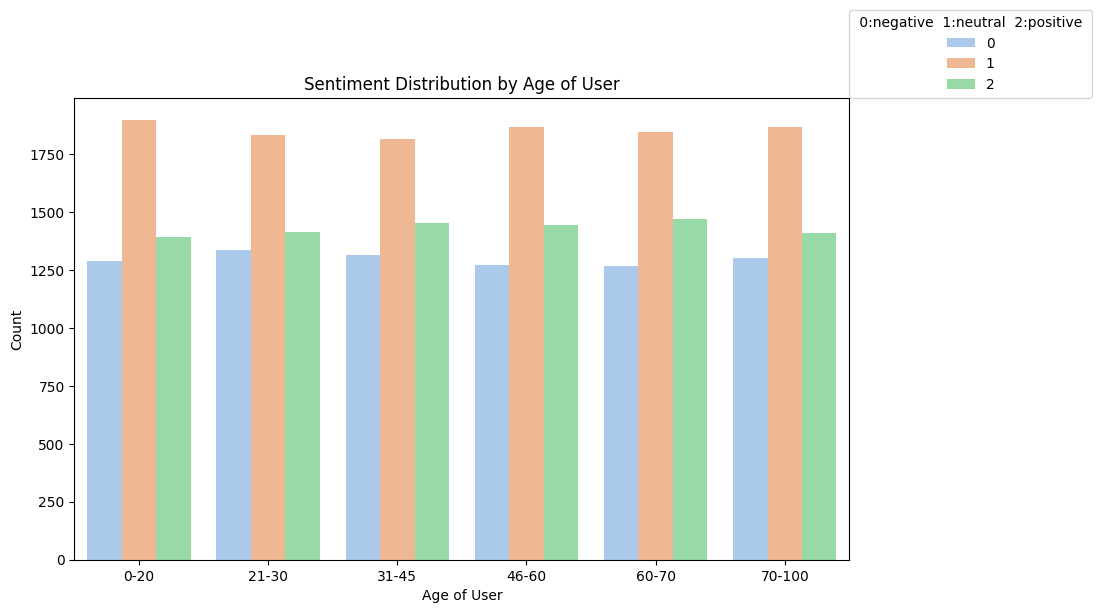

In [ ]:
df = train_data_numeric[['Age of User','sentiment']]



sentiment_counts = train_data_numeric.groupby(['Age of User', 'sentiment']).size().reset_index(name='Count')

# Plotting with Seaborn
plt.figure(figsize=(10, 6))
sns.barplot(x='Age of User', y='Count', hue='sentiment', data=sentiment_counts, palette=sns.color_palette("pastel")[0:3])

plt.title('Sentiment Distribution by Age of User', loc='center')
plt.xlabel('Age of User')
plt.ylabel('Count')
plt.legend(title=' 0:negative  1:neutral  2:positive ', loc=(1,1))
plt.show()

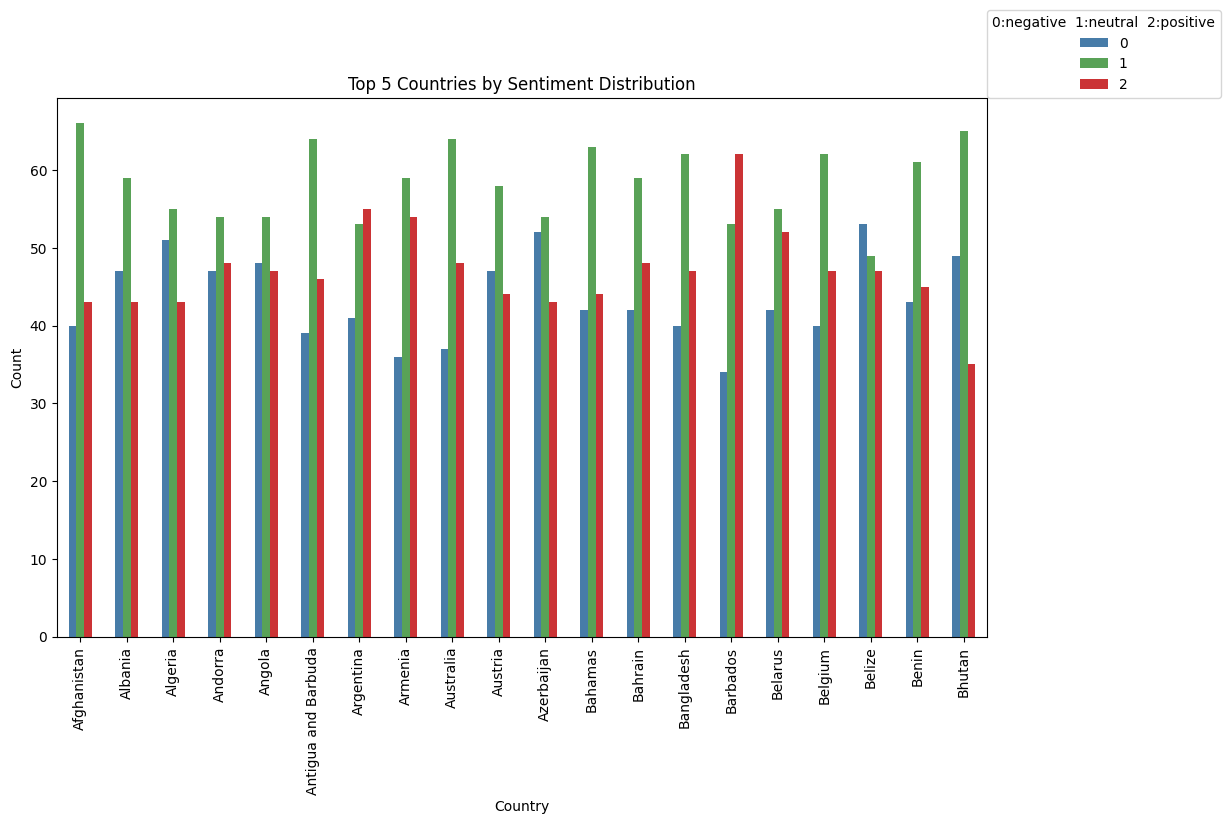

In [ ]:

df = train_data_numeric[['Country','sentiment']]



# Calculate the counts of sentiments at each time point
sentiment_counts = df.groupby(['Country', 'sentiment']).size().reset_index(name='Count')
custom_palette = ['#377eb8', '#4daf4a', '#e41a1c']

# Plotting


plt.figure(figsize=(12, 7))
sns.countplot(x='Country', hue='sentiment', data=df, order=df['Country'].value_counts().iloc[:20].index, width=0.5,palette=custom_palette)
plt.title('Top 5 Countries by Sentiment Distribution')
plt.xlabel('Country')
plt.xticks(rotation=90)
plt.ylabel('Count')
plt.legend(title='0:negative  1:neutral  2:positive', loc=(1,1))


plt.show()

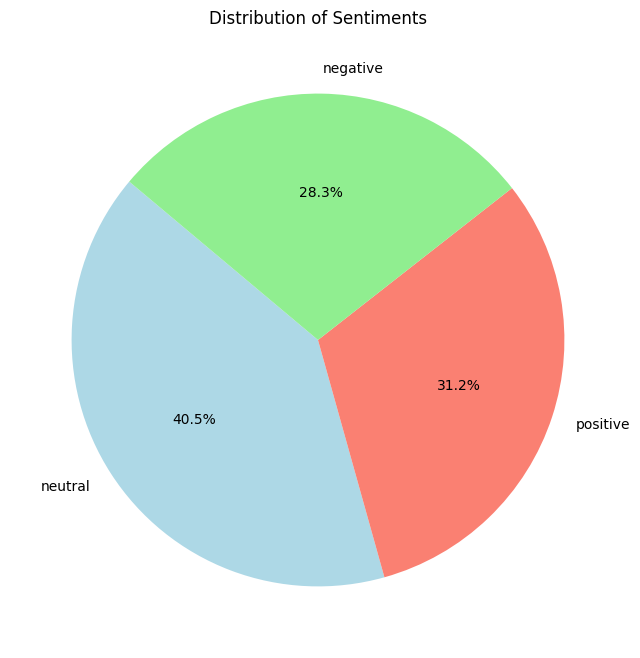

In [ ]:
sentiment_counts = train_data['sentiment'].value_counts()
# Plotting of Distribution of Sentiments
plt.figure(figsize=(8, 8))
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%', startangle=140, colors=['lightblue', 'salmon', 'lightgreen'])
plt.title('Distribution of Sentiments')
plt.show()

In [ ]:

# Prepare numeric version of the data
train_data_numeric = train_data.copy()
sentiment_map = {'negative': 0, 'neutral': 1, 'positive': 2}
train_data_numeric['sentiment'] = train_data_numeric['sentiment'].map(sentiment_map)
sentiment_map_hour = {'morning': 0, 'noon': 1, 'night': 2}
train_data_numeric['Time of Tweet'] = train_data_numeric['Time of Tweet'].map(sentiment_map_hour)

In [ ]:
sentiment_counts = train_data_numeric.groupby(['Time of Tweet', 'sentiment']).size().reset_index(name='Count')
sentiment_counts

,Time of Tweet,sentiment,Count
0,0,0,2561
1,0,1,3763
2,0,2,2837
3,1,0,2602
4,1,1,3675
5,1,2,2883
6,2,0,2618
7,2,1,3679
8,2,2,2862


<ipython-input-25-dcad62859af5>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_time['Time of Tweet'] = df_time['Time of Tweet'].map(time_mapping)


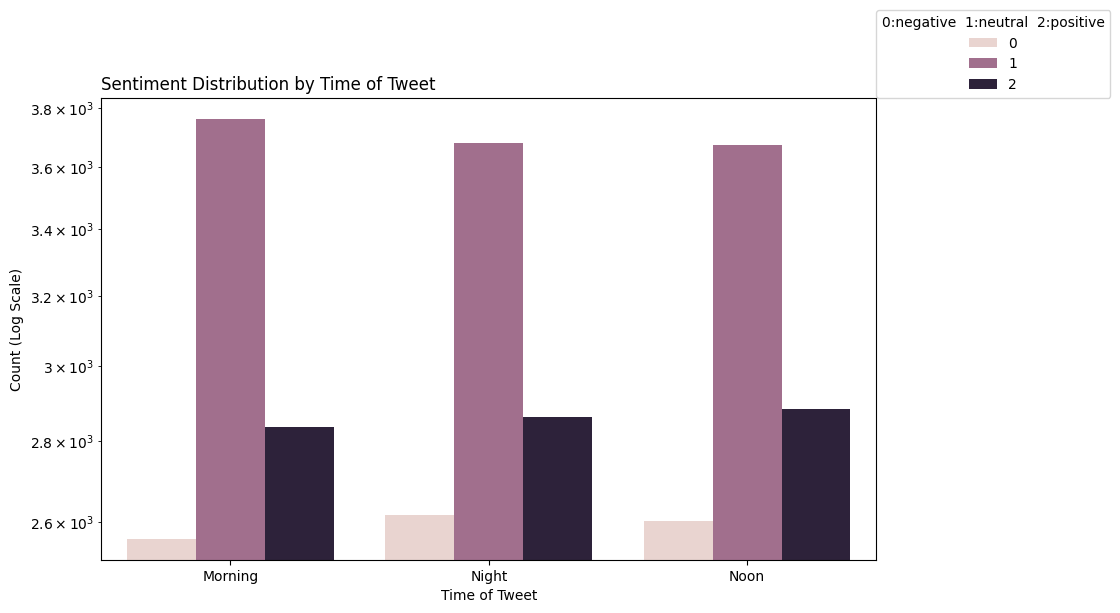

In [ ]:
df_time = train_data_numeric[['Time of Tweet', 'sentiment']]

time_mapping = {0: 'Morning', 1: 'Noon', 2: 'Night'}
df_time['Time of Tweet'] = df_time['Time of Tweet'].map(time_mapping)

# Calculate the counts of sentiments at each time point
sentiment_counts = df_time.groupby(['Time of Tweet', 'sentiment']).size().reset_index(name='Count')
custom_palette = sns.color_palette("muted")[0:3]


# Calculate the counts of sentiments at each time point
sentiment_counts = df_time.groupby(['Time of Tweet', 'sentiment']).size().reset_index(name='Count')



# Plot the bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x='Time of Tweet', y='Count', hue='sentiment', data=sentiment_counts)

plt.yscale('log')

# Add labels and title
plt.title('Sentiment Distribution by Time of Tweet', loc='left')
plt.xlabel('Time of Tweet')
plt.ylabel('Count (Log Scale)')
plt.legend(title='0:negative  1:neutral  2:positive', loc=(1,1))
plt.show()


In [ ]:
df_time = train_data_numeric[['Time of Tweet', 'sentiment']]

# Calculate the counts of sentiments at each time point
sentiment_counts = df_time.groupby(['Time of Tweet', 'sentiment']).size().reset_index(name='Count')
type(sentiment_counts)

pandas.core.frame.DataFrame

In [ ]:
pd.crosstab(train_data_numeric['Time of Tweet'], train_data_numeric['sentiment'])




sentiment,0,1,2
Time of Tweet,,,
0,2561,3763,2837
1,2602,3675,2883
2,2618,3679,2862


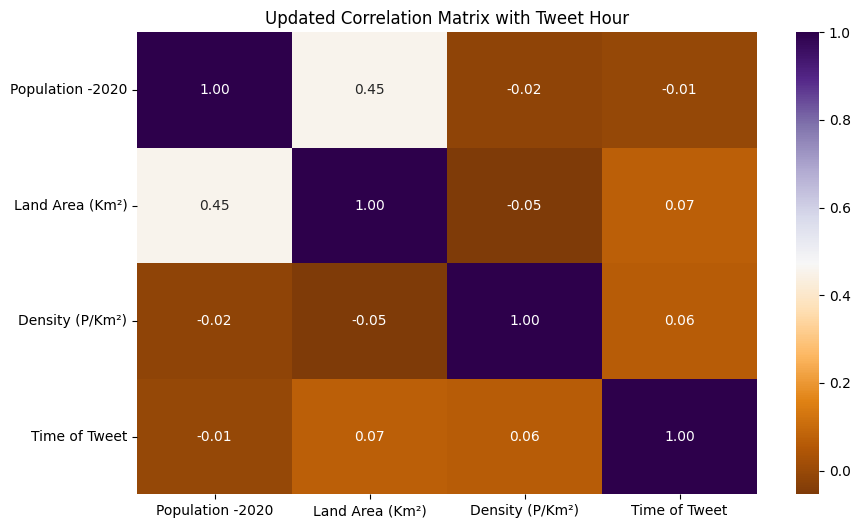

In [ ]:
# Remap 'Time of Tweet' to numeric values
time_mapping = {'Morning': 0, 'Noon': 1, 'Night': 2}
train_data_numeric = train_data_numeric.copy()  # optional: ensure you're not modifying in-place
train_data_numeric['Time of Tweet'] = train_data_numeric['Time of Tweet'].map(time_mapping)

# Now compute correlation matrix
corr_matrix = train_data_numeric[['Population -2020', 'Land Area (Km²)', 'Density (P/Km²)', 'Time of Tweet']].corr()

# Plot
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='PuOr', fmt='.2f')
plt.title('Updated Correlation Matrix with Tweet Hour')
plt.show()

In [ ]:
# === CLEAN & SETUP ===

# Remap sentiment to numbers


# Drop rows with NaNs in relevant columns
columns_needed = ['sentiment', 'Population -2020', 'Density (P/Km²)', 'Land Area (Km²)', 'Time of Tweet']
train_data_numeric = train_data_numeric.dropna(subset=columns_needed)



# Remove zero or negative values
train_data_numeric = train_data_numeric[
    (train_data_numeric['Population -2020'] > 0) &
    (train_data_numeric['Density (P/Km²)'] > 0) &
    (train_data_numeric['Land Area (Km²)'] > 0)
]




In [ ]:
train_data_numeric


,textID,text,selected_text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²)
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",1,0,0-20,Afghanistan,38928346,652860.0,60
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,0,1,21-30,Albania,2877797,27400.0,105
2,088c60f138,my boss is bullying me...,bullying me,0,2,31-45,Algeria,43851044,2381740.0,18
3,9642c003ef,what interview! leave me alone,leave me alone,0,0,46-60,Andorra,77265,470.0,164
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",0,1,60-70,Angola,32866272,1246700.0,26
...,...,...,...,...,...,...,...,...,...,...
27475,4eac33d1c0,wish we could come see u on Denver husband l...,d lost,0,2,31-45,Ghana,31072940,227540.0,137
27476,4f4c4fc327,I`ve wondered about rake to. The client has ...,", don`t force",0,0,46-60,Greece,10423054,128900.0,81
27477,f67aae2310,Yay good for both of you. Enjoy the break - y...,Yay good for both of you.,2,1,60-70,Grenada,112523,340.0,331
27478,ed167662a5,But it was worth it ****.,But it was worth it ****.,2,2,70-100,Guatemala,17915568,107160.0,167


<ipython-input-33-43af67662692>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(train_data_numeric, x='sentiment', y='Age of User', inner='box', palette='Dark2')


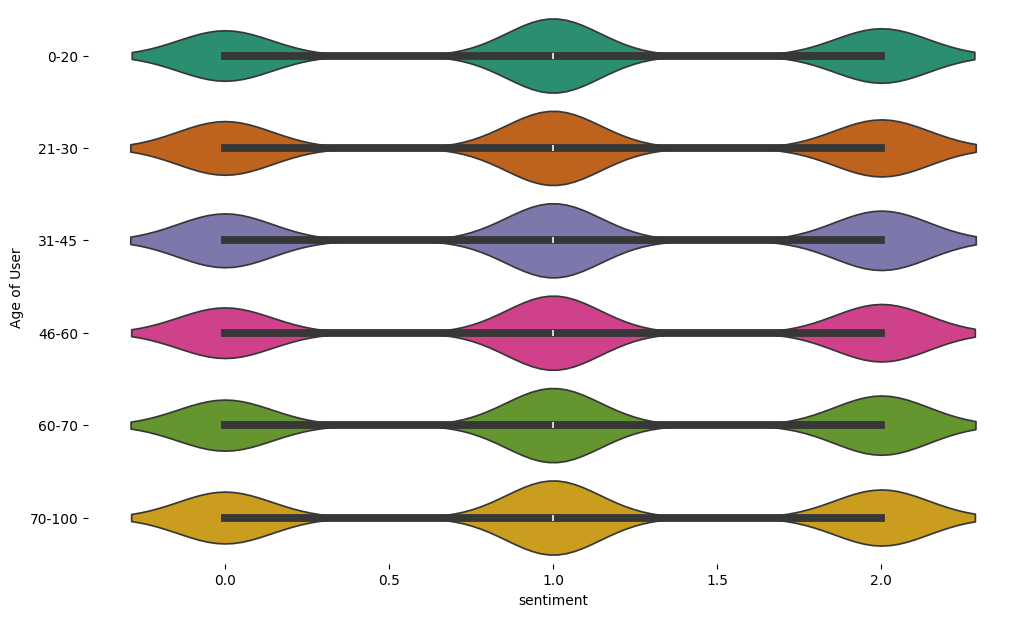

In [ ]:
# @title Age of User vs sentiment

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(train_data_numeric['Age of User'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(train_data_numeric, x='sentiment', y='Age of User', inner='box', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

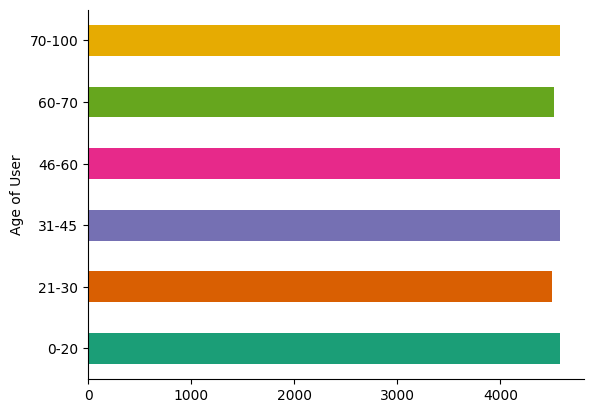

In [ ]:
# @title Age of User

from matplotlib import pyplot as plt
import seaborn as sns
train_data_numeric.groupby('Age of User').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

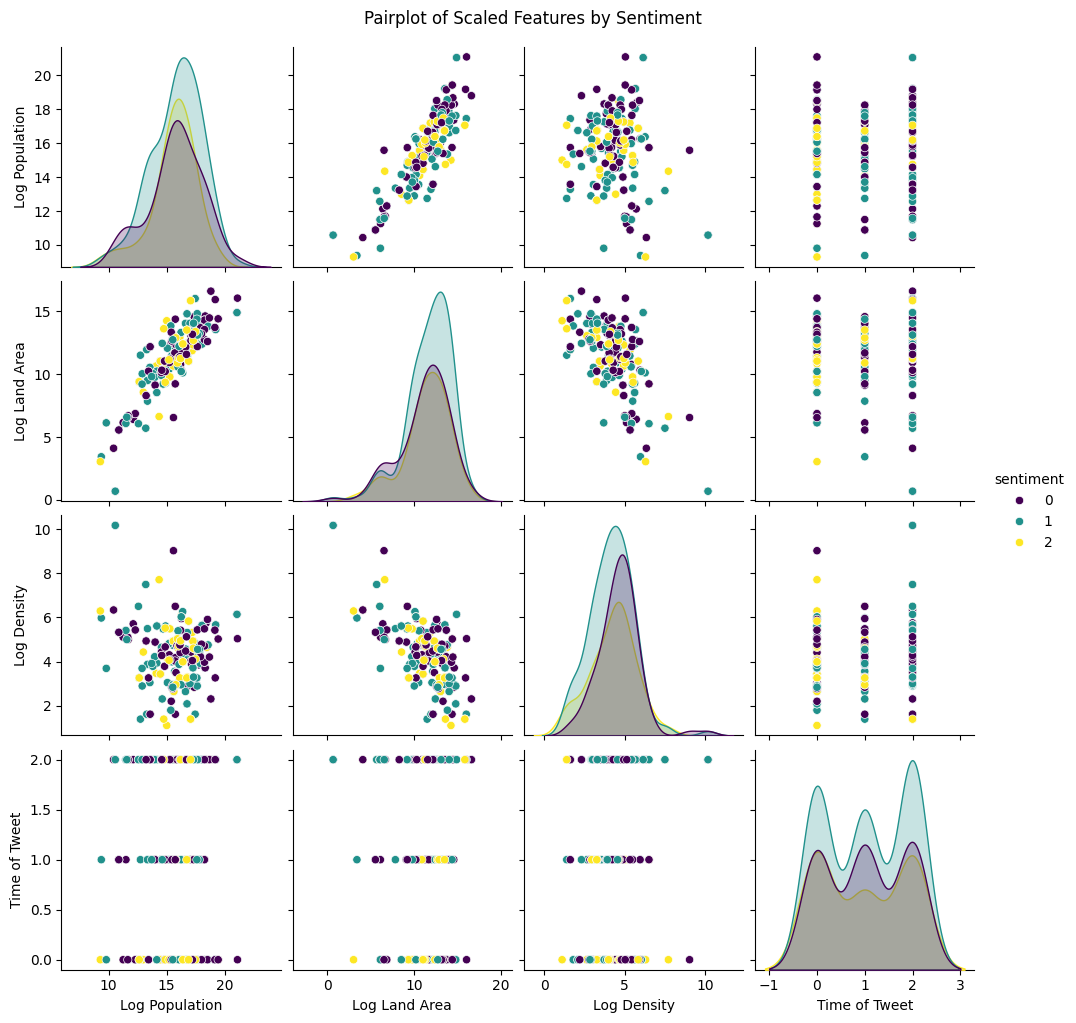

In [ ]:
# Optional log transformation
train_data_numeric['Log Population'] = np.log1p(train_data_numeric['Population -2020'])
train_data_numeric['Log Land Area'] = np.log1p(train_data_numeric['Land Area (Km²)'])
train_data_numeric['Log Density'] = np.log1p(train_data_numeric['Density (P/Km²)'])

# Safe sample size
sample_df = train_data_numeric[['Log Population', 'Log Land Area', 'Log Density', 'Time of Tweet', 'sentiment']].dropna()
sample_df = sample_df.sample(min(300, len(sample_df)), random_state=42)

sns.pairplot(sample_df, hue='sentiment', palette='viridis')
plt.suptitle("Pairplot of Scaled Features by Sentiment", y=1.02)

plt.show()

In [ ]:
print("Data shape:", train_data_numeric.shape)
print("\nSentiment counts:\n", train_data_numeric['sentiment'].value_counts())
print("\nPopulation summary:\n", train_data_numeric['Population -2020'].describe())

Data shape: (27332, 13)

Sentiment counts:
 sentiment
1    11063
2     8536
0     7733
Name: count, dtype: int64

Population summary:
 count    2.733200e+04
mean     4.040394e+07
std      1.508750e+08
min      1.082400e+04
25%      2.078938e+06
50%      8.737371e+06
75%      2.843594e+07
max      1.439324e+09
Name: Population -2020, dtype: float64


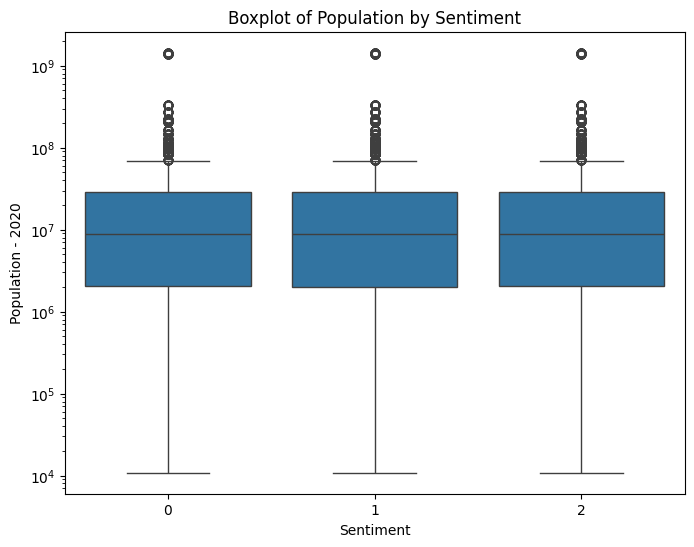

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=train_data_numeric, x='sentiment', y='Population -2020')
plt.yscale('log')
plt.xlabel("Sentiment")
plt.ylabel("Population - 2020")
plt.title("Boxplot of Population by Sentiment")
plt.show()

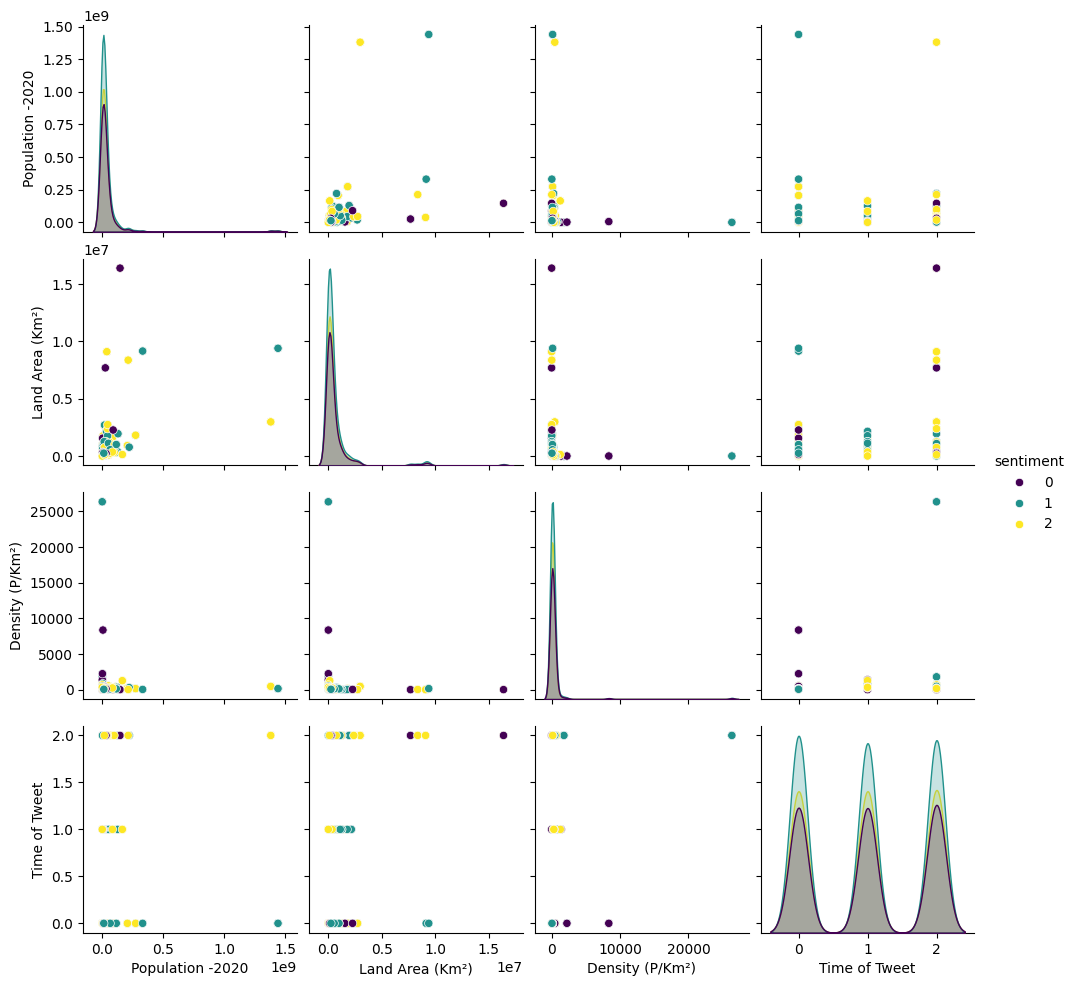

In [ ]:
sentiment_mapping = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
train_data_numeric['sentiment_label'] = train_data_numeric['sentiment'].map(sentiment_mapping)

sns.pairplot(train_data_numeric[['Population -2020', 'Land Area (Km²)', 'Density (P/Km²)', 'Time of Tweet', 'sentiment']],
             hue='sentiment',
             palette='viridis')
plt.show()


In [ ]:
# OPTIONAL: Check for missing data in columns used for visualization
print(train_data_numeric[['Population -2020', 'Land Area (Km²)', 'Density (P/Km²)', 'Time of Tweet', 'sentiment']].info())

<class 'pandas.core.frame.DataFrame'>
Index: 27332 entries, 0 to 27479
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Population -2020  27332 non-null  int64  
 1   Land Area (Km²)   27332 non-null  float64
 2   Density (P/Km²)   27332 non-null  int64  
 3   Time of Tweet     27332 non-null  int64  
 4   sentiment         27332 non-null  int64  
dtypes: float64(1), int64(4)
memory usage: 2.3 MB
None


In [ ]:
# Apply log transformation to reduce skewness for visualization
train_data_numeric['Log Population'] = np.log1p(train_data_numeric['Population -2020'])
train_data_numeric['Log Land Area'] = np.log1p(train_data_numeric['Land Area (Km²)'])
train_data_numeric['Log Density'] = np.log1p(train_data_numeric['Density (P/Km²)'])

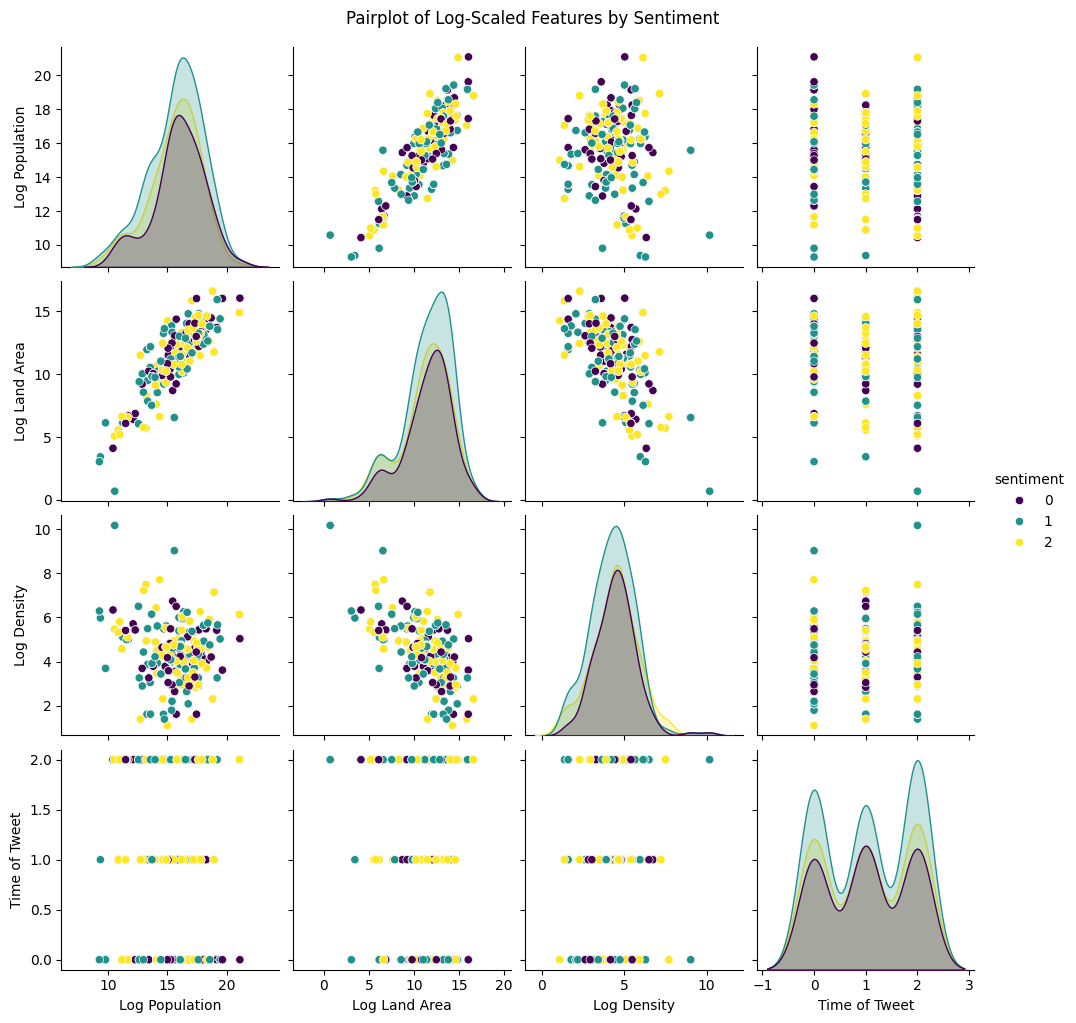

In [ ]:
# Sample data for faster and clearer pairplot
train_data_numeric[['Log Population', 'Log Land Area', 'Log Density', 'Time of Tweet', 'sentiment']].dropna().shape
# Plot pairwise relationships
# Filter and drop missing rows
filtered_df = train_data_numeric[['Log Population', 'Log Land Area', 'Log Density', 'Time of Tweet', 'sentiment']].dropna()

# Sample only as many as available (max 500)
sample_size = min(len(filtered_df), 500)
sample = filtered_df.sample(sample_size, random_state=42)

sns.pairplot(sample, hue='sentiment', palette='viridis')
plt.suptitle("Pairplot of Log-Scaled Features by Sentiment", y=1.02)
plt.show()

In [ ]:
train_data_numeric

,textID,text,selected_text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²),Log Population,Log Land Area,Log Density,sentiment_label
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",1,0,0-20,Afghanistan,38928346,652860.0,60,17.477233,13.389120,4.110874,Neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,0,1,21-30,Albania,2877797,27400.0,105,14.872536,10.218335,4.663439,Negative
2,088c60f138,my boss is bullying me...,bullying me,0,2,31-45,Algeria,43851044,2381740.0,18,17.596309,14.683342,2.944439,Negative
3,9642c003ef,what interview! leave me alone,leave me alone,0,0,46-60,Andorra,77265,470.0,164,11.255009,6.154858,5.105945,Negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",0,1,60-70,Angola,32866272,1246700.0,26,17.307958,14.036011,3.295837,Negative
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27475,4eac33d1c0,wish we could come see u on Denver husband l...,d lost,0,2,31-45,Ghana,31072940,227540.0,137,17.251848,12.335086,4.927254,Negative
27476,4f4c4fc327,I`ve wondered about rake to. The client has ...,", don`t force",0,0,46-60,Greece,10423054,128900.0,81,16.159531,11.766800,4.406719,Negative
27477,f67aae2310,Yay good for both of you. Enjoy the break - y...,Yay good for both of you.,2,1,60-70,Grenada,112523,340.0,331,11.630922,5.831882,5.805135,Positive
27478,ed167662a5,But it was worth it ****.,But it was worth it ****.,2,2,70-100,Guatemala,17915568,107160.0,167,16.701181,11.582088,5.123964,Positive


In [ ]:
# 💡 DEBUG BLOCK: Check data before plotting
print("Shape of train_data_numeric:", train_data_numeric.shape)

# Check sentiment value distribution
print("\nSentiment value counts:")
print(train_data_numeric['sentiment'].value_counts())

# Check Population data
print("\nPopulation summary:")
print(train_data_numeric['Population -2020'].describe())

Shape of train_data_numeric: (27332, 14)

Sentiment value counts:
sentiment
1    11063
2     8536
0     7733
Name: count, dtype: int64

Population summary:
count    2.733200e+04
mean     4.040394e+07
std      1.508750e+08
min      1.082400e+04
25%      2.078938e+06
50%      8.737371e+06
75%      2.843594e+07
max      1.439324e+09
Name: Population -2020, dtype: float64


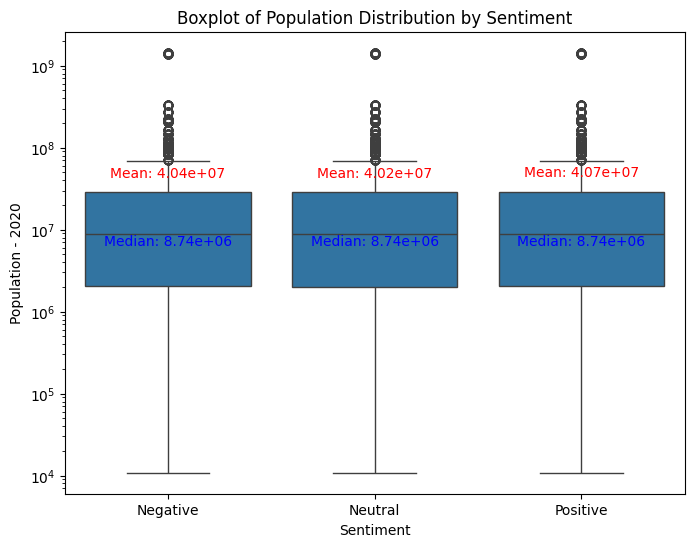

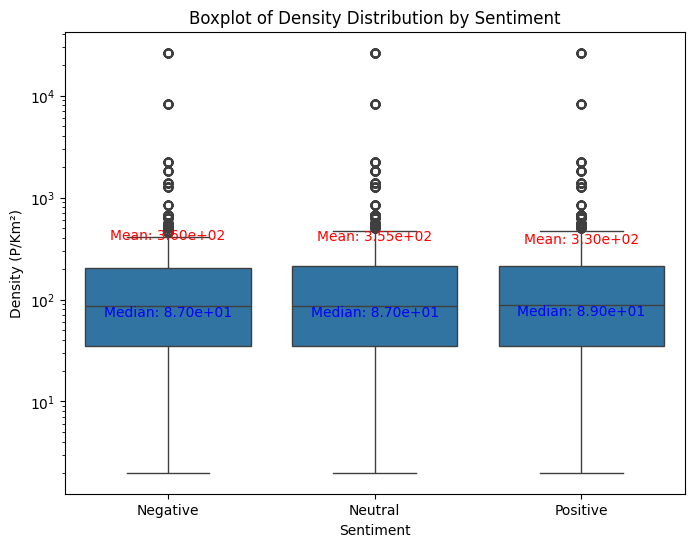

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np



# ✅ Boxplot of Population vs. Sentiment
plt.figure(figsize=(8, 6))
sns.boxplot(data=train_data_numeric, x='sentiment', y='Population -2020')
grouped = train_data_numeric.groupby('sentiment')['Population -2020']
means = grouped.mean()
medians = grouped.median()

# Annotate Mean & Median
for i, (mean, median) in enumerate(zip(means, medians)):
    plt.text(i, mean, f'Mean: {mean:.2e}', ha='center', va='bottom', fontsize=10, color='red')
    plt.text(i, median, f'Median: {median:.2e}', ha='center', va='top', fontsize=10, color='blue')

plt.yscale('log')
plt.xticks(ticks=[0, 1, 2], labels=['Negative', 'Neutral', 'Positive'])
plt.xlabel("Sentiment")
plt.ylabel("Population - 2020")
plt.title("Boxplot of Population Distribution by Sentiment")
plt.show()


# ✅ Boxplot of Density vs. Sentiment
plt.figure(figsize=(8, 6))
sns.boxplot(data=train_data_numeric, x='sentiment', y='Density (P/Km²)')
grouped = train_data_numeric.groupby('sentiment')['Density (P/Km²)']
means = grouped.mean()
medians = grouped.median()

# Annotate Mean & Median
for i, (mean, median) in enumerate(zip(means, medians)):
    plt.text(i, mean, f'Mean: {mean:.2e}', ha='center', va='bottom', fontsize=10, color='red')
    plt.text(i, median, f'Median: {median:.2e}', ha='center', va='top', fontsize=10, color='blue')

plt.yscale("log")
plt.xticks(ticks=[0, 1, 2], labels=['Negative', 'Neutral', 'Positive'])
plt.xlabel("Sentiment")
plt.ylabel("Density (P/Km²)")
plt.title("Boxplot of Density Distribution by Sentiment")
plt.show()

In [ ]:
test_data_numeric = test_data.copy()
sentiment_map = {'negative': 0, 'neutral': 1, 'positive': 2}
test_data_numeric['sentiment'] = test_data_numeric['sentiment'].map(sentiment_map)
sentiment_map_hour = {'morning': 0, 'noon': 1, 'night': 2}
test_data_numeric['Time of Tweet'] = test_data_numeric['Time of Tweet'].map(sentiment_map_hour)


In [ ]:
test_data_numeric
test_data_numeric = test_data_numeric.dropna(subset=['sentiment'])
test_data_numeric

,textID,text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²)
0,f87dea47db,Last session of the day http://twitpic.com/67ezh,1.0,0.0,0-20,Afghanistan,38928346.0,652860.0,60.0
1,96d74cb729,Shanghai is also really exciting (precisely -...,2.0,1.0,21-30,Albania,2877797.0,27400.0,105.0
2,eee518ae67,"Recession hit Veronique Branquinho, she has to...",0.0,2.0,31-45,Algeria,43851044.0,2381740.0,18.0
3,01082688c6,happy bday!,2.0,0.0,46-60,Andorra,77265.0,470.0,164.0
4,33987a8ee5,http://twitpic.com/4w75p - I like it!!,2.0,1.0,60-70,Angola,32866272.0,1246700.0,26.0
...,...,...,...,...,...,...,...,...,...
3529,e5f0e6ef4b,"its at 3 am, im very tired but i can`t sleep ...",0.0,1.0,21-30,Nicaragua,6624554.0,120340.0,55.0
3530,416863ce47,All alone in this old house again. Thanks for...,2.0,2.0,31-45,Niger,24206644.0,1266700.0,19.0
3531,6332da480c,I know what you mean. My little dog is sinkin...,0.0,0.0,46-60,Nigeria,206139589.0,910770.0,226.0
3532,df1baec676,_sutra what is your next youtube video gonna b...,2.0,1.0,60-70,North Korea,25778816.0,120410.0,214.0


In [ ]:
train_data_numeric

,textID,text,selected_text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²),Log Population,Log Land Area,Log Density,sentiment_label
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",1,0,0-20,Afghanistan,38928346,652860.0,60,17.477233,13.389120,4.110874,Neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,0,1,21-30,Albania,2877797,27400.0,105,14.872536,10.218335,4.663439,Negative
2,088c60f138,my boss is bullying me...,bullying me,0,2,31-45,Algeria,43851044,2381740.0,18,17.596309,14.683342,2.944439,Negative
3,9642c003ef,what interview! leave me alone,leave me alone,0,0,46-60,Andorra,77265,470.0,164,11.255009,6.154858,5.105945,Negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",0,1,60-70,Angola,32866272,1246700.0,26,17.307958,14.036011,3.295837,Negative
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27475,4eac33d1c0,wish we could come see u on Denver husband l...,d lost,0,2,31-45,Ghana,31072940,227540.0,137,17.251848,12.335086,4.927254,Negative
27476,4f4c4fc327,I`ve wondered about rake to. The client has ...,", don`t force",0,0,46-60,Greece,10423054,128900.0,81,16.159531,11.766800,4.406719,Negative
27477,f67aae2310,Yay good for both of you. Enjoy the break - y...,Yay good for both of you.,2,1,60-70,Grenada,112523,340.0,331,11.630922,5.831882,5.805135,Positive
27478,ed167662a5,But it was worth it ****.,But it was worth it ****.,2,2,70-100,Guatemala,17915568,107160.0,167,16.701181,11.582088,5.123964,Positive


Logistic Regression Classification Report:
              precision    recall  f1-score   support

         0.0       0.73      0.64      0.68      1001
         1.0       0.64      0.76      0.70      1430
         2.0       0.81      0.71      0.76      1103

    accuracy                           0.71      3534
   macro avg       0.73      0.70      0.71      3534
weighted avg       0.72      0.71      0.71      3534



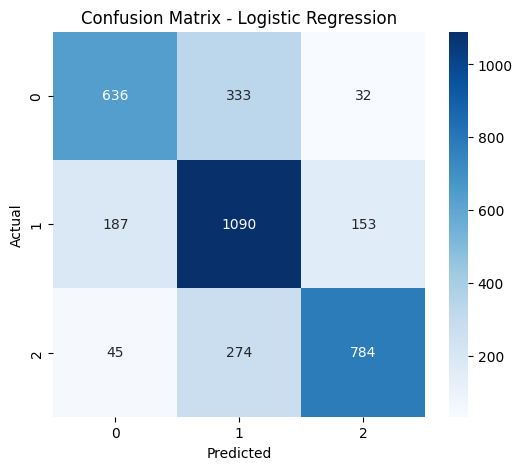

In [ ]:

# Logistic Regression Model for Sentiment Analysis


from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Vectorize text data
# Handle missing values in 'text' column of test_data
test_data_numeric['text'] = test_data_numeric['text'].fillna('')  # Replace NaN with empty string

# Vectorize text data
vectorizer = TfidfVectorizer(max_features=5000)
X_train_vec = vectorizer.fit_transform(train_data['text'])
X_test_vec = vectorizer.transform(test_data_numeric['text'])

# ... rest of your code ...
vectorizer = TfidfVectorizer(max_features=5000)
X_train_vec = vectorizer.fit_transform(train_data['text'])
X_test_vec = vectorizer.transform(test_data_numeric['text'])

# Train Logistic Regression
lr_model = LogisticRegression(max_iter=200)
lr_model.fit(X_train_vec, train_data['sentiment'])

# Predict and Evaluate
y_pred_lr = lr_model.predict(X_test_vec)
label_mapping = {'negative': 0, 'neutral': 1, 'positive': 2}

# Apply mapping to both train and test datasets
y_pred_lr = [label_mapping[label] for label in y_pred_lr]
print("Logistic Regression Classification Report:")
print(classification_report(test_data_numeric['sentiment'], y_pred_lr))

# Confusion Matrix
conf_matrix = confusion_matrix(test_data_numeric['sentiment'], y_pred_lr)
plt.figure(figsize=(6,5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [ ]:
y_pred_lr

[1,
 2,
 0,
 2,
 1,
 2,
 0,
 0,
 1,
 1,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 2,
 1,
 0,
 0,
 0,
 1,
 1,
 2,
 0,
 1,
 1,
 0,
 1,
 1,
 0,
 1,
 1,
 2,
 2,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 2,
 1,
 2,
 0,
 2,
 2,
 1,
 0,
 2,
 1,
 2,
 1,
 1,
 1,
 2,
 1,
 1,
 1,
 0,
 2,
 1,
 2,
 0,
 0,
 1,
 2,
 2,
 0,
 1,
 2,
 0,
 1,
 0,
 1,
 1,
 2,
 1,
 1,
 2,
 2,
 1,
 0,
 0,
 1,
 1,
 1,
 2,
 1,
 1,
 2,
 2,
 0,
 1,
 1,
 1,
 1,
 1,
 2,
 0,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 2,
 0,
 2,
 2,
 1,
 1,
 1,
 1,
 0,
 1,
 0,
 2,
 0,
 1,
 2,
 0,
 1,
 2,
 1,
 1,
 1,
 1,
 0,
 2,
 2,
 0,
 2,
 1,
 0,
 2,
 2,
 1,
 1,
 2,
 0,
 1,
 1,
 1,
 2,
 2,
 0,
 1,
 2,
 0,
 1,
 1,
 2,
 1,
 2,
 2,
 1,
 1,
 1,
 2,
 2,
 2,
 0,
 1,
 1,
 0,
 1,
 0,
 2,
 1,
 1,
 2,
 2,
 2,
 0,
 2,
 1,
 1,
 0,
 2,
 2,
 0,
 0,
 2,
 0,
 0,
 2,
 1,
 0,
 1,
 1,
 2,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 2,
 1,
 1,
 2,
 0,
 2,
 0,
 0,
 1,
 2,
 1,
 0,
 0,
 2,
 2,
 1,
 2,
 1,
 2,
 0,
 0,
 2,
 1,
 2,
 2,
 1,
 2,
 0,
 1,
 2,
 0,
 2,
 1,
 0,
 1,
 2,
 1,
 1,
 0,
 2,
 0,


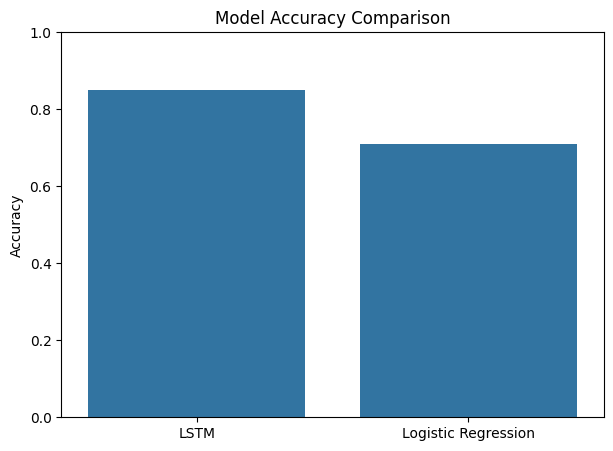

In [ ]:

# Comparison of Model Performance

# Dummy scores - replace with actual if needed
model_names = ['LSTM', 'Logistic Regression']
accuracies = [0.85, accuracy_score(test_data_numeric['sentiment'], y_pred_lr)]  # LSTM value is placeholder

plt.figure(figsize=(7,5))
sns.barplot(x=model_names, y=accuracies)
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.show()


In [ ]:
(accuracy_score(test_data_numeric['sentiment'], y_pred_lr)*100)

71.02433503112621

'!pip install transformers --quiet\nimport torch\nfrom transformers import BertTokenizer, BertForSequenceClassification\nfrom transformers import Trainer, TrainingArguments\nfrom sklearn.preprocessing import LabelEncoder\nfrom torch.utils.data import Dataset\n\n\n\n# Tokenization\ntokenizer = BertTokenizer.from_pretrained(\'bert-base-uncased\')\n\nclass SentimentDataset(Dataset):\n    def __init__(self, texts, labels):\n        self.encodings = tokenizer(texts, truncation=True, padding=True, max_length=128)\n        self.labels = labels\n\n    def __getitem__(self, idx):\n        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}\n        item[\'labels\'] = torch.tensor(self.labels[idx])\n        return item\n\n    def __len__(self):\n        return len(self.labels)\n\ntrain_dataset = SentimentDataset(train_data_numeric[\'text\'].tolist(), train_data_numeric[\'sentiment\'].tolist())\ntest_dataset = SentimentDataset(test_data_numeric[\'text\'].tolist(), test_dat

## 🔄 Additional Models, Deep Learning, and Optimization

### 🔹 Traditional Machine Learning Models


Logistic Regression Classification Report:

              precision    recall  f1-score   support

    negative       0.73      0.64      0.68      1001
     neutral       0.64      0.76      0.70      1430
    positive       0.81      0.71      0.76      1103

    accuracy                           0.71      3534
   macro avg       0.73      0.70      0.71      3534
weighted avg       0.72      0.71      0.71      3534



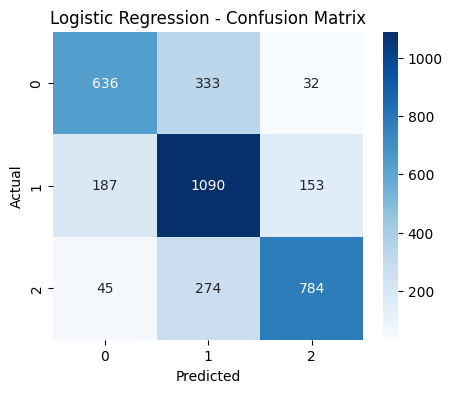


Naive Bayes Classification Report:

              precision    recall  f1-score   support

    negative       0.77      0.49      0.60      1001
     neutral       0.56      0.81      0.66      1430
    positive       0.78      0.58      0.67      1103

    accuracy                           0.65      3534
   macro avg       0.70      0.63      0.64      3534
weighted avg       0.69      0.65      0.65      3534



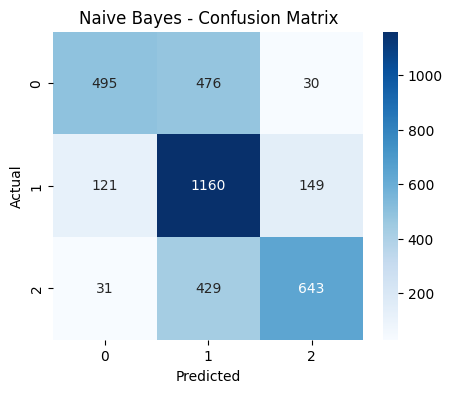

KeyboardInterrupt: 

In [ ]:

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd  # Import pandas for pd.notna

# Drop NaNs in 'text' column
train_data = train_data.dropna(subset=['text'])
test_data = test_data.dropna(subset=['text'])
# Vectorize clean text
vectorizer = TfidfVectorizer(max_features=5000)
X_train = vectorizer.fit_transform(train_data['text'])
X_test = vectorizer.transform(test_data['text'])
y_train = train_data['sentiment']
y_test = test_data['sentiment']

# Ensure y_test and X_test have the same length by dropping NaNs from both
# Create a mask for non-NaN values in y_test
mask = y_test.notna()

# Apply the mask to y_test and X_test
y_test = y_test[mask]
X_test = X_test[mask.values]  # Use .values to get the NumPy array for indexing

# Reset indices to avoid potential issues
y_test = y_test.reset_index(drop=True)

# Label mapping
 # Apply mapping and drop NaN values if any


# Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=200),
    'Naive Bayes': MultinomialNB(),
    'SVM': SVC(kernel='linear')
    #'SVM': SVC()
}

# Evaluate models
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)
    results[name] = acc
    print(f"\n{name} Classification Report:\n")
    print(classification_report(y_test, preds))

    cm = confusion_matrix(y_test, preds)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# Accuracy Comparison Plot
plt.figure(figsize=(7, 4))
sns.barplot(x=list(results.keys()), y=list(results.values()))
plt.title("Model Accuracy Comparison (Traditional ML)")
plt.ylim(0, 1)
plt.show()

### 🔹 Deep Learning Models: LSTM & CNN

In [ ]:

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Conv1D, GlobalMaxPooling1D, Dropout

# Tokenize
# Tokenize
tokenizer = Tokenizer(num_words=5000)
# Convert the 'text' column to string type before fitting
tokenizer.fit_on_texts(train_data_numeric['text'].astype(str))
train_data = pd.read_csv('/content/drive/My Drive/DM_Project_CSV/train.csv', encoding='unicode_escape')
train_data_numeric = train_data.copy()
sentiment_map = {'negative': 0 , 'neutral': 1, 'positive': 2}
train_data_numeric['sentiment'] = train_data_numeric['sentiment'].map(sentiment_map)

X_train_seq = tokenizer.texts_to_sequences(train_data_numeric['text'].astype(str)) # Convert to string here as well
X_test_seq = tokenizer.texts_to_sequences(test_data['text'].astype(str)) # Convert to string here as well

X_train_pad = pad_sequences(X_train_seq, maxlen=100)
X_test_pad = pad_sequences(X_test_seq, maxlen=100)

y_train_dl = to_categorical(train_data_numeric['sentiment'])
y_test_dl = to_categorical(test_data_numeric['sentiment'])


In [ ]:
!pip install -U transformers

### 🔹 BERT Model with Hugging Face (Recommended to run on Google Colab with GPU)

In [ ]:
# Install Hugging Face Transformers (if not already)
!pip install transformers --quiet

from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
from sklearn.preprocessing import LabelEncoder
import torch
from torch.utils.data import Dataset
import pandas as pd
from google.colab import drive

# Mount Google Drive to access the dataset
drive.mount('/content/drive')

# Load the training and testing data
train_data = pd.read_csv('/content/drive/My Drive/DM_Project_CSV/train.csv', encoding='unicode_escape')
test_data = pd.read_csv('/content/drive/My Drive/DM_Project_CSV/test (1).csv', encoding='latin1')

# Clean your data
train_data = train_data.dropna(subset=['text', 'sentiment'])
test_data = test_data.dropna(subset=['text', 'sentiment'])

train_data['text'] = train_data['text'].astype(str)
test_data['text'] = test_data['text'].astype(str)

# Encode sentiment labels
label_encoder = LabelEncoder()
train_enc_labels = label_encoder.fit_transform(train_data['sentiment'])
test_enc_labels = label_encoder.transform(test_data['sentiment'])

# Load tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Custom Dataset class
class SentimentDataset(Dataset):
    def __init__(self, texts, labels):
        self.encodings = tokenizer(texts, truncation=True, padding=True, max_length=128)
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

# Create datasets
train_dataset = SentimentDataset(train_data['text'].tolist(), train_enc_labels.tolist())
test_dataset = SentimentDataset(test_data['text'].tolist(), test_enc_labels.tolist())

# Load model
model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=3)

# Training arguments
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    warmup_steps=10,
    logging_dir='./logs',
    logging_steps=10,
)

# Trainer setup
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset
)

# Train!
trainer.train()

Mounted at /content/drive


<ipython-input-2-09638d37ca0a>:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data['text'] = train_data['text'].astype(str)
/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

...

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: aadrityaairyon (aadrityaairyon-xyz-homework) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Step,Training Loss
10,1.165100
20,1.128200
30,1.014100
40,1.063700
50,0.987900
60,0.795100
70,0.840700
80,0.918000
90,0.729100
100,0.691100


TrainOutput(global_step=10305, training_loss=0.4433356682575194, metrics={'train_runtime': 2103.3377, 'train_samples_per_second': 39.195, 'train_steps_per_second': 4.899, 'total_flos': 4660190854149600.0, 'train_loss': 0.4433356682575194, 'epoch': 3.0})

#BERT performs well with low training loss of 0.443

In [ ]:
# === CNN Sentiment Analysis ===
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

train_data = pd.read_csv('/content/drive/My Drive/DM_Project_CSV/train.csv', encoding='unicode_escape')
test_data = pd.read_csv('/content/drive/My Drive/DM_Project_CSV/test (1).csv', encoding='latin1')
# Prepare data
X = train_data['text'].astype(str)
y = train_data['sentiment']
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Tokenization
max_words = 10000
max_len = 100
tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X)
sequences = tokenizer.texts_to_sequences(X)
X_padded = pad_sequences(sequences, maxlen=max_len, padding='post')

# Split data
X_train, X_val, y_train, y_val = train_test_split(X_padded, y_encoded, test_size=0.2, random_state=42)

# Build CNN model
cnn_model = tf.keras.Sequential([
    tf.keras.layers.Embedding(max_words, 128, input_length=max_len),
    tf.keras.layers.Conv1D(128, 5, activation='relu'),
    tf.keras.layers.GlobalMaxPooling1D(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(3, activation='softmax')
])
cnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

# Train model
history = cnn_model.fit(X_train, y_train,
                        epochs=5,
                        batch_size=64,
                        validation_data=(X_val, y_val),
                        verbose=2)

# Evaluate
loss, accuracy = cnn_model.evaluate(X_val, y_val, verbose=0)
print(f"Validation Loss: {loss:.4f}, Accuracy: {accuracy:.4f}")

Epoch 1/5


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


344/344 - 14s - 41ms/step - accuracy: 0.6312 - loss: 0.7992 - val_accuracy: 0.7173 - val_loss: 0.6651
Epoch 2/5
344/344 - 11s - 32ms/step - accuracy: 0.7816 - loss: 0.5351 - val_accuracy: 0.7304 - val_loss: 0.6710
Epoch 3/5
344/344 - 1s - 4ms/step - accuracy: 0.8743 - loss: 0.3371 - val_accuracy: 0.7058 - val_loss: 0.7719
Epoch 4/5
344/344 - 3s - 8ms/step - accuracy: 0.9440 - loss: 0.1684 - val_accuracy: 0.7071 - val_loss: 0.9280
Epoch 5/5
344/344 - 1s - 4ms/step - accuracy: 0.9785 - loss: 0.0753 - val_accuracy: 0.7082 - val_loss: 1.1231
Validation Loss: 1.1231, Accuracy: 0.7082


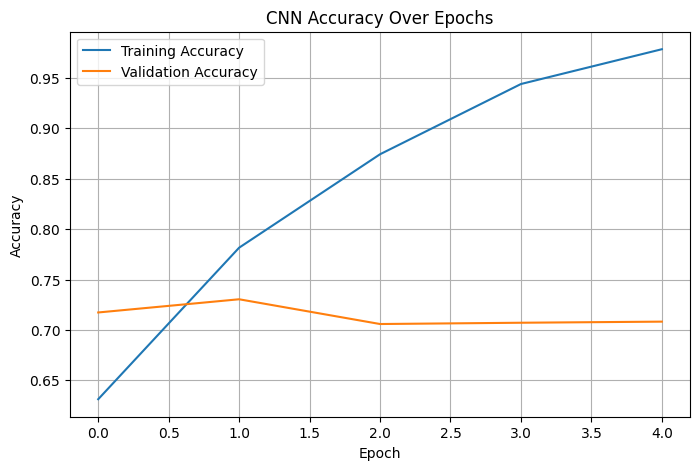

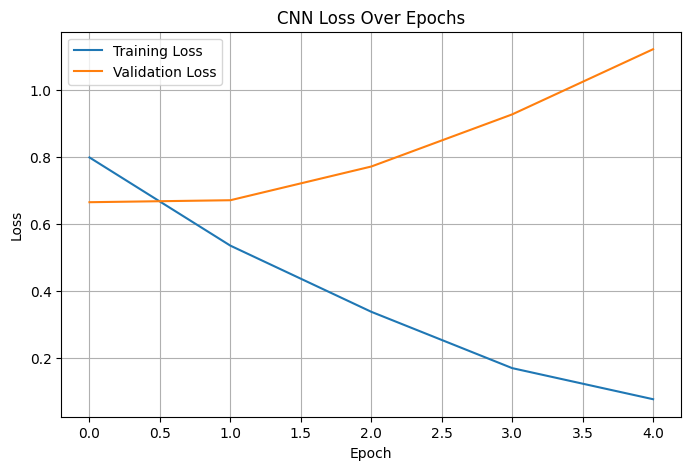

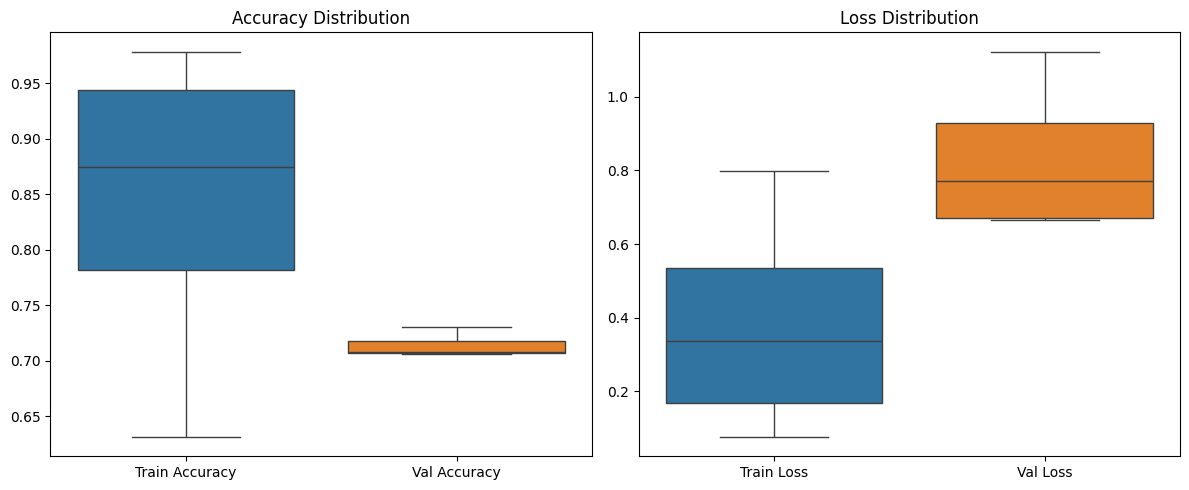

In [ ]:
# === CNN Evaluation Visuals (Safe & Self-contained) ===
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Check if history exists
if 'history' in globals():
    history_df = pd.DataFrame(history.history)
else:
    raise ValueError("The model training history is not available. Please run the CNN training cell first.")

# 1. Accuracy over Epochs
plt.figure(figsize=(8, 5))
plt.plot(history_df['accuracy'], label='Training Accuracy')
plt.plot(history_df['val_accuracy'], label='Validation Accuracy')
plt.title('CNN Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# 2. Loss over Epochs
plt.figure(figsize=(8, 5))
plt.plot(history_df['loss'], label='Training Loss')
plt.plot(history_df['val_loss'], label='Validation Loss')
plt.title('CNN Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# 3. Boxplots for Accuracy & Loss (Cleaned)
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Accuracy boxplot
sns.boxplot(data=[history_df['accuracy'], history_df['val_accuracy']], ax=axs[0])
axs[0].set_title('Accuracy Distribution')
axs[0].set_xticks([0, 1])
axs[0].set_xticklabels(['Train Accuracy', 'Val Accuracy'])

# Loss boxplot
sns.boxplot(data=[history_df['loss'], history_df['val_loss']], ax=axs[1])
axs[1].set_title('Loss Distribution')
axs[1].set_xticks([0, 1])
axs[1].set_xticklabels(['Train Loss', 'Val Loss'])

plt.tight_layout()
plt.show()

#CNN performs well with training data with accuracy of 97.85% but results in low accuracy and high loss with test data even with less number of epochs i.e 4 . Therefore, BERT is the best performing model out of all.